This notebook is to play around with gui code for visualizing data online

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any

In [3]:
# Load config
import sys
import os
from pathlib import Path


# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))

home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config
Configuration loaded successfully:
data_subfolders:
  day: 20250717
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data
  table_parameters:
    PreprocessParams:
      window_length: 60
      poly_order: 3
      non_negative: 1
      subtract_baseline: 0
      standardize: 1
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
        framerate: 5
    DNoiseTraceParams:
      dnoise_params_id: 1
      fupsample_trace: 20
      fupsample_stim: 4
      ref_time: stim
      fit_kind: gradient
      skip_duplicates: true


In [4]:
cfg.paths.repo_directory

'/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/'

In [5]:
# # hydra in notebooks behaves differently. 
# # Need to overwrite the configs dynamicaly set at runtime 
# from datetime import datetime
# output_dir = f"{cfg.paths.repo_directory}/logs/outputs/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
# OmegaConf.update(cfg, "model_configs.paths.output_dir", output_dir)


In [6]:
cfg.model_configs.paths.output_dir

'output'

In [7]:
# 
from simulations.loop_components.dj_wrappers import DJTableHolder,Preprocessor,QualityAndTypeWrapper,STAWrapper,RandomSeedMEIWrapper

# connect populated closed loop schema

In [8]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )

In [11]:
# # Load config and tables

dj_table_holder.load_config()
dj_table_holder.load_tables()
# dj_table_holder.clear_tables("all")

# print(" loaded and configured successfully")
#dj_table_holder.setup()




[2025-08-02 21:12:08,619][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-08-02 21:12:08,677][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop


In [14]:
dj_table_holder("OpenRetinaHoeflingFormat")().delete()

[2025-08-02 21:13:17,640][INFO]: Deleting 1 rows from `ageuler_ssuhai_closed_loop`.`open_retina_hoefling_format`


[2025-08-02 21:13:20,517][INFO]: Deletes committed.


1

In [15]:
preprocessor = Preprocessor(dj_table_holder=dj_table_holder)

In [16]:
quality_type_analysis_wrapper = QualityAndTypeWrapper(
    dj_table_holder=dj_table_holder,)

sta_wrapper = STAWrapper(
    dj_table_holder=dj_table_holder,)

randomp_seed_mei_wrapper = RandomSeedMEIWrapper(
    dj_table_holder=dj_table_holder,
    model_configs=cfg.model_configs, 
    seeds= [123,456,789])

In [17]:
preprocessor.upload_iteration_metadata()

Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20200226/1
		header_name: 20200226__left.ini
		Already present: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2020, 2, 26, 0, 0), 'exp_num': 1}
Found 4 files in 1 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'raw_id': 1}
	Skipping field `{'field': 'GCL0', 'region': 'LR', 'cond1': 'iter0', 'experimenter': 'closedlooptest', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'raw_id': 1}` because it already exists


Processes: 100%|██████████| 2/2 [00:00<00:00, 27.48it/s]


# GUI Components for Visualization

Let's create a basic GUI to visualize the data processed by the OpenRetinaWrapper.

In [ ]:
dj_table_holder("CelltypeAssignment").delete()

[2025-08-02 16:12:27,052][INFO]: Deleting 103 rows from `ageuler_ssuhai_closed_loop`.`__celltype_assignment`


[2025-08-02 16:12:30,552][INFO]: Deletes committed.


103

In [18]:
missing_keys = dj_table_holder("RoiMask")().list_missing_field()
if missing_keys == []:
    missing_keys = [dj_table_holder("Field")().proj().fetch1()]

missing_keys


[{'experimenter': 'closedlooptest',
  'date': datetime.date(2020, 2, 26),
  'exp_num': 1,
  'raw_id': 1,
  'field': 'GCL0',
  'region': 'LR',
  'cond1': 'iter0'}]

# modified autorois 

In [19]:
from simulations.gui.integrated_autorois import InteractiveRoiCanvas
# import ipywidgets as widgets
# from ipycanvas import MultiCanvas
from IPython.display import display     # # # Calculate position in microns



Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

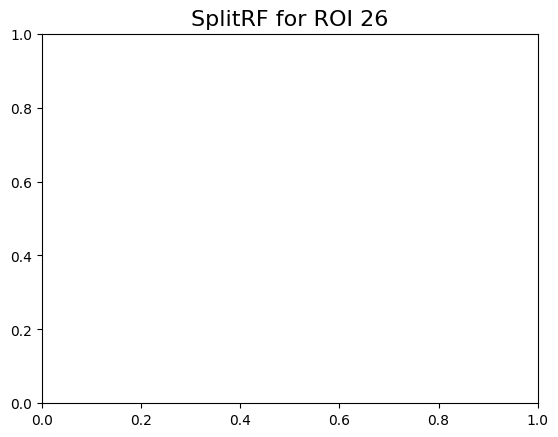

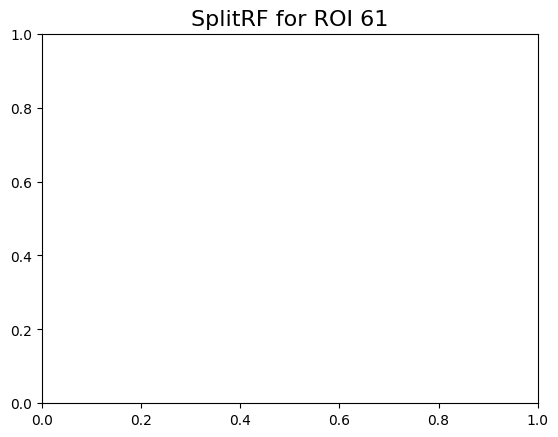

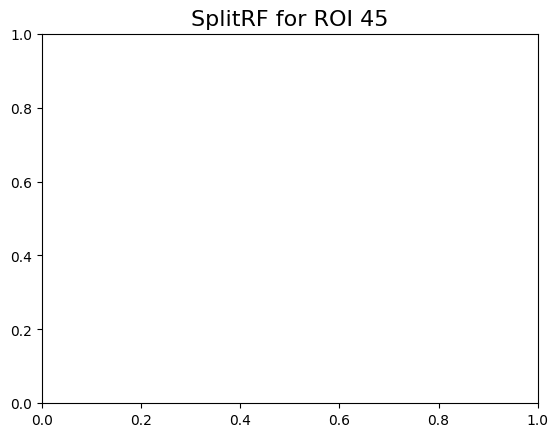

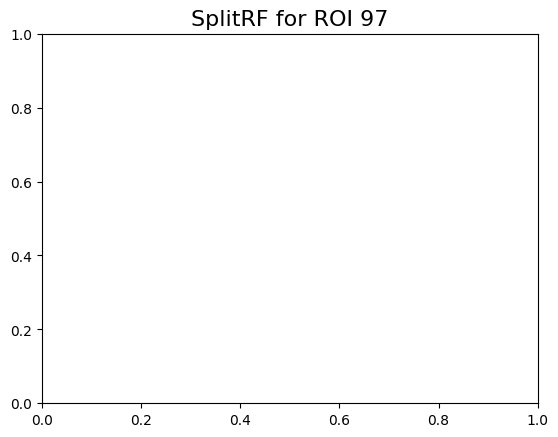

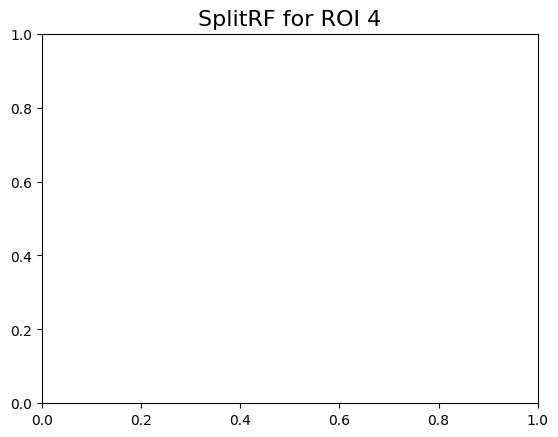

In [22]:
mod_autorois = InteractiveRoiCanvas(
    dj_table_holder=dj_table_holder,
    dj_preprocessor=preprocessor,
    all_dj_wrappers=[quality_type_analysis_wrapper,sta_wrapper,randomp_seed_mei_wrapper],
    field_key=missing_keys[0],
    canvas_width=30,
    )

In [23]:
display(mod_autorois.start_gui()) 

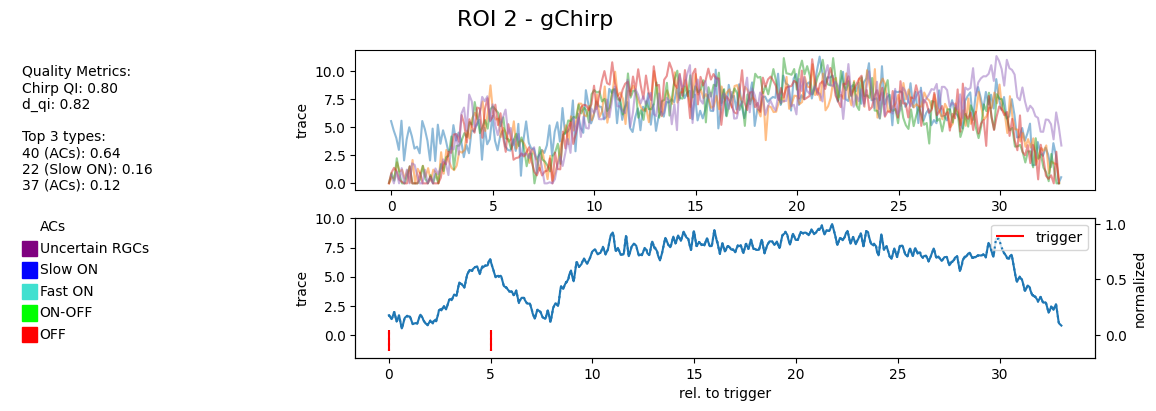

In [27]:
quality_type_analysis_wrapper.plot1(2)

# investigate MEI and RF positioning

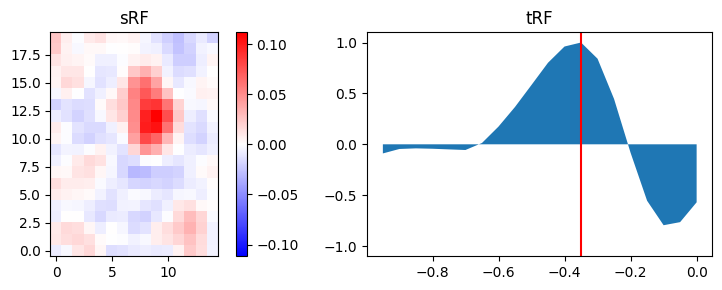

<Figure size 640x480 with 0 Axes>

In [ ]:
sta_wrapper.plot1(5)

In [28]:
spatial_readout = randomp_seed_mei_wrapper.model.readout['online_session_1_ventral1_20200226']

In [30]:
mask_mean = randomp_seed_mei_wrapper.model.readout['online_session_1_ventral1_20200226'].mask_mean.detach().cpu().numpy()
mask_mean.shape

(65, 2)

In [31]:
import torch


In [119]:
spatial_readout.grid.shape

torch.Size([65, 8, 6, 2])

ROI 32, mask_mean: [ 0.03925829 -0.16302185]


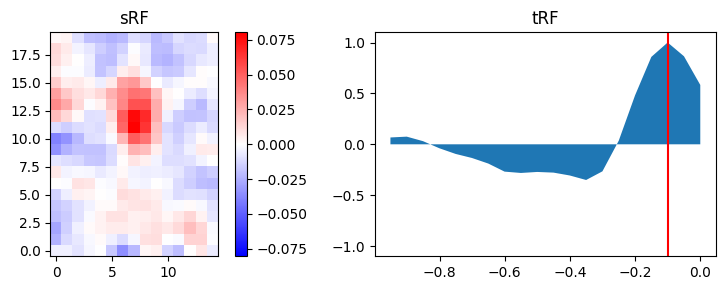

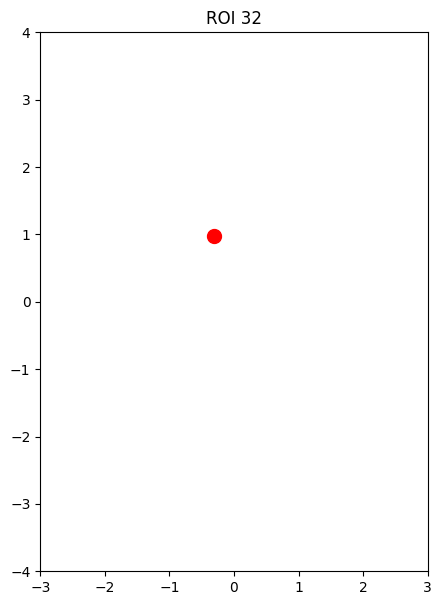

In [34]:
import matplotlib.pyplot as plt
def compare_srf_and_mask_mean(idx):
    roi = randomp_seed_mei_wrapper.rois_after_filtering[idx]
    print(f"ROI {roi}, mask_mean: {mask_mean[idx]}")
    w_scale,h_scale = mask_mean[idx]

    # make negative
    w_scale = -w_scale
    h_scale = -h_scale

    sta_wrapper.plot1(roi)
    fig,ax = plt.subplots(figsize= (5,7))
    ax.scatter(w_scale * 8, h_scale * 6, c='red', s=100, label='Mask Mean')
    ax.set_xlim([-3, 3])
    ax.set_ylim([-4,4])
    ax.set_title(f"ROI {roi}")

compare_srf_and_mask_mean(19)

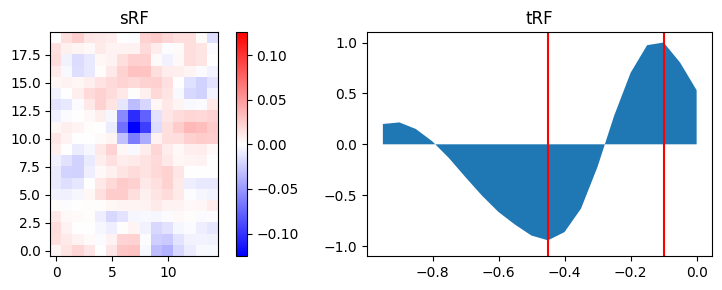

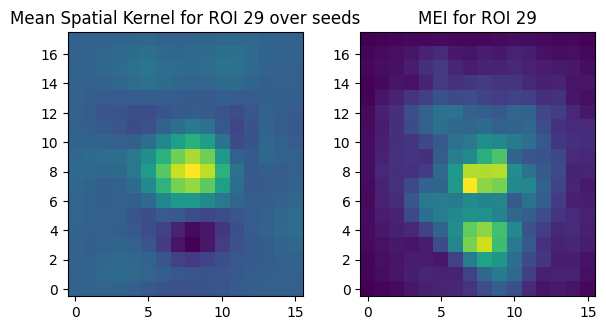

In [35]:
import numpy as np
def compare_srf_with_mei(idx):
    roi = randomp_seed_mei_wrapper.rois_after_filtering[idx]


    # plot srf 
    sta_wrapper.plot1(roi)

    # take average over seeds
    all_meis = torch.stack(list(randomp_seed_mei_wrapper.neuron_seed_mei_dict[idx].values()))

    mean_mei = torch.mean(all_meis, dim=0).detach().cpu().numpy()

    # max projection acros time and channels 
    abs_mean_mei_max = np.max(np.abs(mean_mei), axis=(0, 1))
    fig,axs = plt.subplots(1, 2, figsize=(6, 6))

    # plot mean_mei
    axs[1].imshow(np.flip(abs_mean_mei_max), origin='lower')
    axs[1].set_title(f"MEI for ROI {roi}")
    
    # take mean decomposed staptial kernel and plot it
    all_seed_kernels = []
    for seed in randomp_seed_mei_wrapper.seeds:
        spatial_kernels = randomp_seed_mei_wrapper.neuron_seed_decomposed_meis[idx][seed]["spatial_kernels"]
        mean_spatial_kernel = np.mean(spatial_kernels,axis = 0)
        all_seed_kernels.append(mean_spatial_kernel)
        
    mean_spatial_kernel_over_seeds = np.mean(all_seed_kernels, axis=0)

    axs[0].imshow(np.flip(mean_spatial_kernel_over_seeds), origin='lower')
    axs[0].set_title(f"Mean Spatial Kernel for ROI {roi} over seeds")

    plt.tight_layout()
    plt.show()

compare_srf_with_mei(17)





    

In [ ]:
srf = (dj_table_holder("SplitRF")() & {"roi_id": 29}).fetch1("srf")
idx_srf_max = np.argmax(np.abs(srf))
reshaped_idx_max = np.unravel_index(idx_srf_max, srf.shape)

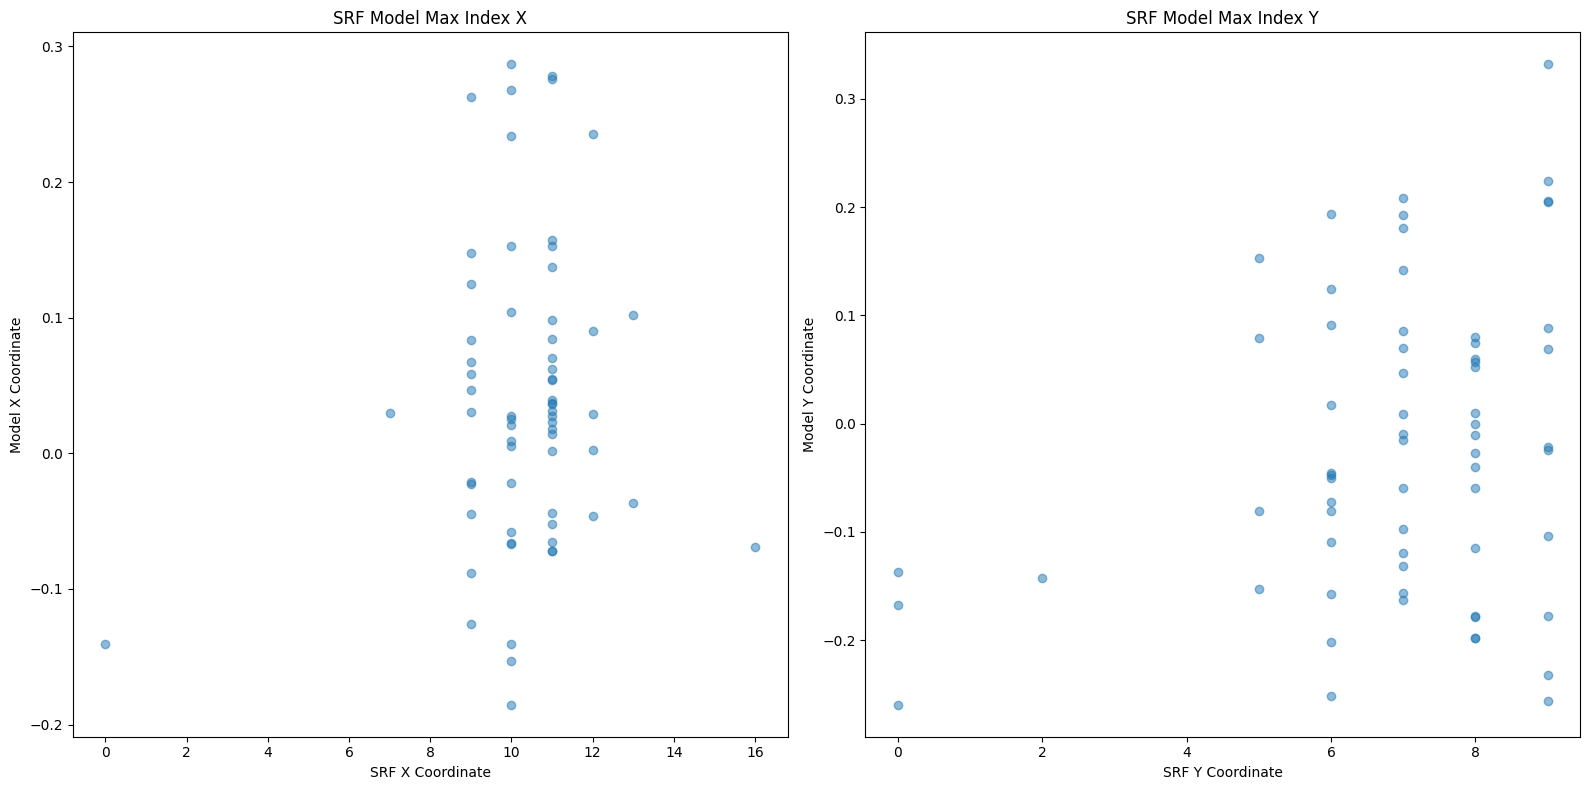

In [46]:
def plot_srf_mask_mean_scatter():
    """Plots a scatterplot to compare the SRF and mask mean coordinates."""
    all_x_coords_srf = []
    all_y_coords_srf = []
    all_x_coords_model = []
    all_y_coords_model = []

    for idx in range(len(randomp_seed_mei_wrapper.rois_after_filtering)):
        roi = randomp_seed_mei_wrapper.rois_after_filtering[idx]
        srf = (dj_table_holder("SplitRF")() & {"roi_id": roi}).fetch1("srf")
        mask_mean = randomp_seed_mei_wrapper.model.readout['online_session_1_ventral1_20200226'].mask_mean[idx].detach().cpu().numpy()

        # get the max index of the srf
        idx_srf_max = np.argmax(np.abs(srf))
        reshaped_idx_max = np.unravel_index(idx_srf_max, srf.shape)

        x_srf, y_srf = reshaped_idx_max
        x_model, y_model = mask_mean

        all_x_coords_srf.append(x_srf)
        all_y_coords_srf.append(y_srf)
        all_x_coords_model.append(x_model)
        all_y_coords_model.append(y_model)

    # plot the scatter plot
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
    ax[0].scatter(all_x_coords_srf, all_x_coords_model, alpha=0.5)
    ax[0].set_title('SRF Model Max Index X')
    ax[0].set_xlabel('SRF X Coordinate')
    ax[0].set_ylabel('Model X Coordinate')

    ax[1].scatter(all_y_coords_srf, all_y_coords_model, alpha=0.5)
    ax[1].set_title('SRF Model Max Index Y')
    ax[1].set_xlabel('SRF Y Coordinate')
    ax[1].set_ylabel('Model Y Coordinate')

    plt.tight_layout()
    plt.show()

plot_srf_mask_mean_scatter()


In [42]:
def plot_srf_mei_scatter():
    all_x_coords_srf = []
    all_y_coords_srf = []
    all_x_coords_model = []
    all_y_coords_model = []

    for idx in range(len(randomp_seed_mei_wrapper.rois_after_filtering)):
        roi = randomp_seed_mei_wrapper.rois_after_filtering[idx]
        
        #roi = np.random.choice(randomp_seed_mei_wrapper.rois_after_filtering)
        
        srf = (dj_table_holder("SplitRF")() & {"roi_id": roi}).fetch1("srf")
        
        # Get weighted average for SRF
        weights = np.abs(srf)  # Use absolute values as weights
        # Create coordinate matrices
        y_coords, x_coords = np.meshgrid(np.arange(srf.shape[1]), np.arange(srf.shape[0]))
        
        # Calculate weighted means
        total_weight = np.sum(weights)
        if total_weight > 0:  # Avoid division by zero
            x_srf = np.sum(x_coords * weights) / total_weight
            y_srf = np.sum(y_coords * weights) / total_weight
        else:
            x_srf, y_srf = 0, 0
            
        # take mean decomposed spatial kernel and plot it
        all_seed_kernels = []
        for seed in randomp_seed_mei_wrapper.seeds:
            spatial_kernels = randomp_seed_mei_wrapper.neuron_seed_decomposed_meis[idx][seed]["spatial_kernels"]
            mean_spatial_kernel = np.mean(spatial_kernels, axis=0)
            all_seed_kernels.append(mean_spatial_kernel)
            
        mean_spatial_kernel_over_seeds = np.mean(all_seed_kernels, axis=0)
        
        # Get weighted average for model kernel
        weights_model = np.abs(mean_spatial_kernel_over_seeds)
        # Create coordinate matrices for model
        y_coords_model, x_coords_model = np.meshgrid(
            np.arange(mean_spatial_kernel_over_seeds.shape[1]), 
            np.arange(mean_spatial_kernel_over_seeds.shape[0])
        )
        
        # Calculate weighted means for model
        total_weight_model = np.sum(weights_model)
        if total_weight_model > 0:  # Avoid division by zero
            x_model = np.sum(x_coords_model * weights_model) / total_weight_model
            y_model = np.sum(y_coords_model * weights_model) / total_weight_model
        else:
            x_model, y_model = 0, 0

        

        all_x_coords_srf.append(x_srf)
        all_y_coords_srf.append(y_srf)
        all_x_coords_model.append(x_model)
        all_y_coords_model.append(y_model)
    
    # plot the scatter plot
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
    ax[0].scatter(all_x_coords_srf, all_x_coords_model, alpha=0.5)
    ax[0].set_title('SRF Model Weighted Center X')
    ax[0].set_xlabel('SRF X Coordinate')
    ax[0].set_ylabel('Model X Coordinate')
    # Uncomment the following lines to set limits
    ax[0].set_xlim([0, 20])
    ax[0].set_ylim([0, 18])
    ax[0].set_xlim([0, 20])
    ax[0].set_ylim([0, 18])
    ax[1].scatter(all_y_coords_srf, all_y_coords_model, alpha=0.5)
    ax[1].set_title('SRF Model Weighted Center Y')
    ax[1].set_xlabel('SRF Y Coordinate')
    ax[1].set_ylabel('Model Y Coordinate')
    # Uncomment the following lines to set limits
    ax[1].set_xlim([0, 15])
    ax[1].set_ylim([0, 16])
    
    
    return fig, ax

(<Figure size 1600x800 with 2 Axes>,
 array([<Axes: title={'center': 'SRF Model Weighted Center X'}, xlabel='SRF X Coordinate', ylabel='Model X Coordinate'>,
        <Axes: title={'center': 'SRF Model Weighted Center Y'}, xlabel='SRF Y Coordinate', ylabel='Model Y Coordinate'>],
       dtype=object))

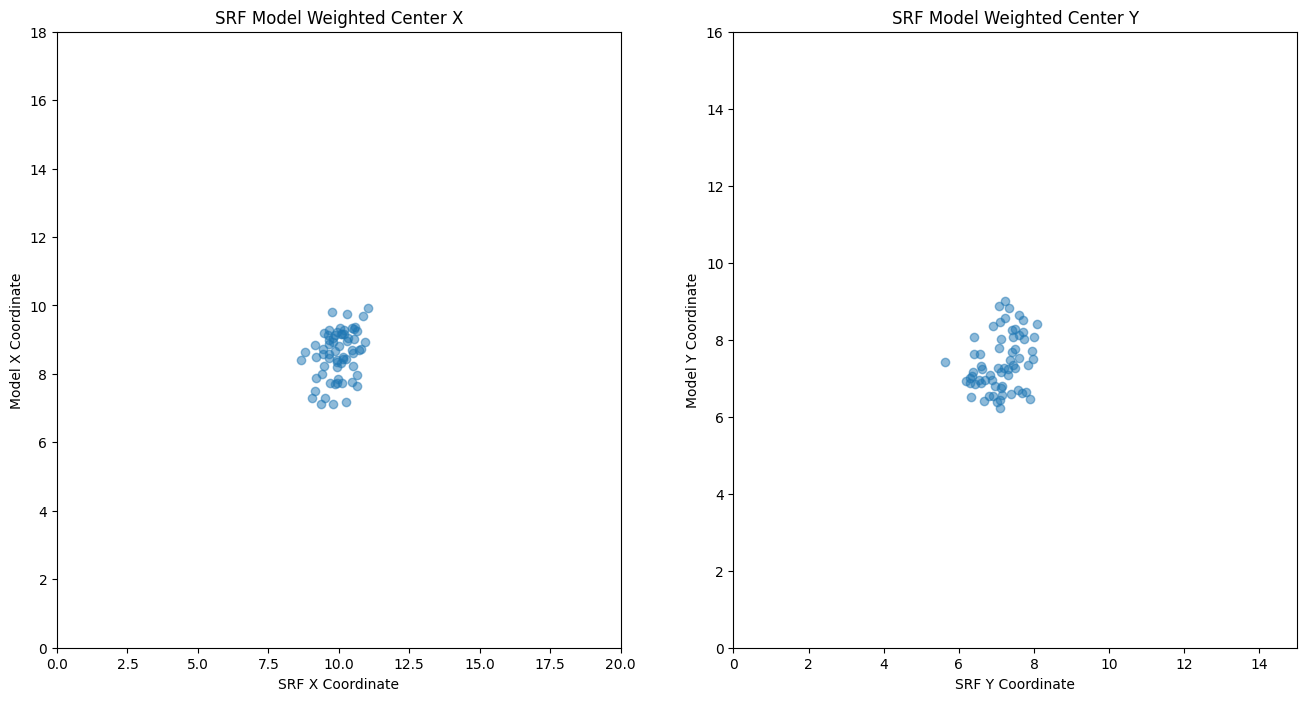

In [43]:
plot_srf_mei_scatter()

In [40]:
# make some scatter plots of dRF max index and spatial kernel max index
def plot_srf_mei_scatter(transform_to_qdspy = False):

    all_x_coords_srf = []
    all_y_coords_srf = []
    all_x_coords_model = []
    all_y_coords_model = []

    for idx in range(len(randomp_seed_mei_wrapper.rois_after_filtering)):
        roi = randomp_seed_mei_wrapper.rois_after_filtering[idx]

        srf = (dj_table_holder("SplitRF")() & {"roi_id": roi}).fetch1("srf")
        idx_srf_max = np.argmax(np.abs(srf))
        reshaped_idx_max = np.unravel_index(idx_srf_max, srf.shape)

        # take mean decomposed staptial kernel and plot it
        all_seed_kernels = []
        for seed in randomp_seed_mei_wrapper.seeds:
            spatial_kernels = randomp_seed_mei_wrapper.neuron_seed_decomposed_meis[idx][seed]["spatial_kernels"]
            mean_spatial_kernel = np.mean(spatial_kernels,axis = 0)
            all_seed_kernels.append(mean_spatial_kernel)
            
        mean_spatial_kernel_over_seeds = np.mean(all_seed_kernels, axis=0)

        # get the max index of the mean spatial kernel
        idx_spatial_max = np.argmax(np.abs(mean_spatial_kernel_over_seeds))
        reshaped_idx_spatial_max = np.unravel_index(idx_spatial_max, mean_spatial_kernel_over_seeds.shape)

        # get the x and y coordinates of the max index
        x_srf, y_srf = reshaped_idx_max
        x_model, y_model = reshaped_idx_spatial_max

        if transform_to_qdspy:
            x_srf -= 10
            x_model -= 9
            y_srf -= 7.5
            y_model -= 8

            # scale by pixel size: 50 model 30 srf i think 
            x_srf *= 30
            y_srf *= 30

            x_model *= 50
            y_model *= 50


        all_x_coords_srf.append(x_srf)
        all_y_coords_srf.append(y_srf)
        all_x_coords_model.append(x_model)
        all_y_coords_model.append(y_model)
    
    # plot the scatter plot
    fig, ax = plt.subplots(1,2,figsize=(8, 8))
    ax[0].scatter(all_x_coords_srf, all_x_coords_model, alpha=0.5)
    ax[0].set_title('SRF Model Max Index X')

    ax[1].scatter(all_y_coords_srf, all_y_coords_model, alpha=0.5)
    ax[1].set_title('SRF Model Max Index Y')
    
    
    if not transform_to_qdspy:
        ax[0].set_xlim([0,20])
        ax[0].set_ylim([0,18])
    
        ax[1].set_xlim([0,15])
        ax[1].set_ylim([0,16])
    else:
        ax[0].set_xlim([-200, 200])
        ax[0].set_ylim([-200, 200])

        ax[1].set_xlim([-200, 200])
        ax[1].set_ylim([-200, 200])




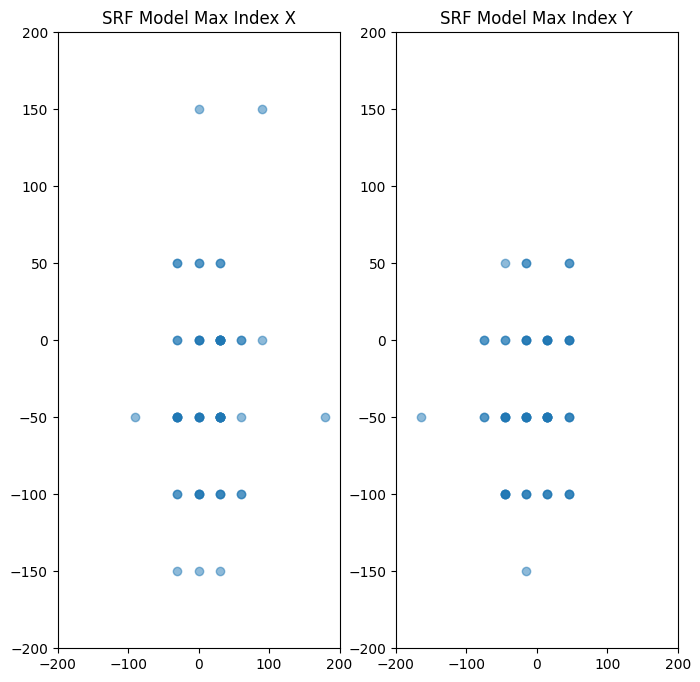

In [41]:
plot_srf_mei_scatter(True)

In [25]:
(dj_table_holder("Stimulus")() & {'stim_family': 'noise'}).fetch1("stim_dict")

{'ntrigger_per_frame': 1,
 'pix_n_x': 20,
 'pix_n_y': 15,
 'pix_scale_x_um': 40,
 'pix_scale_y_um': 40,
 'offset_x_um': 0,
 'offset_y_um': 0}

In [36]:
#dj_table_holder("CascadeTraces")()
dj_table_holder("OpenRetinaHoeflingFormat")().delete()

[2025-08-01 17:59:34,441][INFO]: Deleting 1 rows from `ageuler_ssuhai_closed_loop`.`open_retina_hoefling_format`
--- Logging error ---
Traceback (most recent call last):
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/logging/__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
ValueError: I/O operation on closed file.
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/tornado/platform/asy

[2025-08-01 17:59:37,268][INFO]: Deletes committed.
--- Logging error ---
Traceback (most recent call last):
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/logging/__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
ValueError: I/O operation on closed file.
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/.pyenv/versions/miniconda3-latest/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_foreve

1

In [25]:
randomp_seed_mei_wrapper.rois_after_filtering

[4,
 5,
 7,
 8,
 11,
 12,
 14,
 15,
 16,
 17,
 18,
 22,
 23,
 25,
 26,
 27,
 28,
 29,
 30,
 32,
 34,
 35,
 36,
 37,
 39,
 40,
 41,
 42,
 43,
 45,
 46,
 47,
 49,
 50,
 52,
 54,
 55,
 58,
 59,
 62,
 65,
 66,
 68,
 69,
 70,
 73,
 74,
 76,
 77,
 80,
 81,
 82,
 83,
 85,
 89,
 90,
 92,
 93,
 94,
 95,
 98,
 100,
 102,
 103,
 104]

In [23]:
session_dict = dj_table_holder("OpenRetinaHoeflingFormat")().extract_data()

In [ ]:
session_dict

In [29]:
class bla:
    quality_checks = {}

In [30]:
from simulations.loop_components.model_to_stimulus import preprocess_for_openretina

processed_session_dict = preprocess_for_openretina(session_dict,cfg.model_configs)
default_processed = preprocess_for_openretina(session_dict,bla)

Original dataset contains 103 neurons over 1 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (1 remaining)
Overall, dropped 17 neurons of non-target cell types (-16.50%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (1 remaining)
Overall, dropped 9 neurons over quality checks (-10.47%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 12 neurons with classifier confidences below 0.25 (-15.58%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 65 neurons over 1 fields
Total number of cells dropped: 38 (-36.89%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/1 [00:00<?, ?it/s]

Total number of cells dropped: 32 (-31.07%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
len(processed_session_dict['online_session_1_ventral1_20200226'].session_kwargs["roi_ids"])

65

In [36]:
len(default_processed['online_session_1_ventral1_20200226'].session_kwargs["roi_ids"])

71

In [20]:
len(randomp_seed_mei_wrapper.rois_after_filtering)

65

In [33]:
print(1+ 1)
test_dict = randomp_seed_mei_wrapper.compute_analysis()

2
Original dataset contains 103 neurons over 1 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (1 remaining)
Overall, dropped 17 neurons of non-target cell types (-16.50%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (1 remaining)
Overall, dropped 9 neurons over quality checks (-10.47%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 12 neurons with classifier confidences below 0.25 (-15.58%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 65 neurons over 1 fields
Total number of cells dropped: 38 (-36.89%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/1 [00:00<?, ?it/s]

Creating movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/gpfs01/euler/User/ssuhai/.local/lib/python3.12/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory output/csv/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/gpfs01/euler/User/ssuhai/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /gpfs01/euler/User/ssuhai/output/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                        | Params | Mode 
-------------------------------------------------------------------------
0 | core             | SimpleCoreWrapper           | 12.4 K | train
1 | readout          | MultiGaussianReadoutWrapper | 67.4 K | train
2 | loss             | PoissonLoss3d               | 0      | train
3 | correlation_loss | Co

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Monitored metric val_correlation did not improve in the last 10 records. Best score: 0.335. Signaling Trainer to stop.
Restoring states from the checkpoint path at /gpfs01/euler/User/ssuhai/output/checkpoints/epoch=43_val_correlation=0.336-v3.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /gpfs01/euler/User/ssuhai/output/checkpoints/epoch=43_val_correlation=0.336-v3.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃       DataLoader 1        ┃       DataLoader 2        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_correlation      │    0.2822074890136719     │     0.335659384727478     │     0.512474775314331     │
│         test_loss         │     904.0782470703125     │      494.8701171875       │    52.171791076660156     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

Seed set to 42


Function train_model_online took 17.456594 seconds to execute.


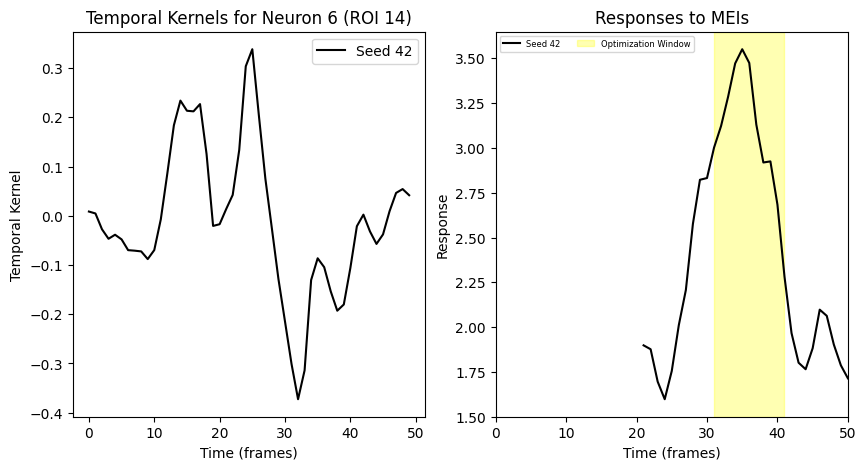

In [51]:
randomp_seed_mei_wrapper.plot1(roi_id=14)

In [18]:
import numpy as np
np.where(np.isnan(test_dict["online_session_1_ventral1_20200226"]["natural_spikes"][0]))

(array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
          11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
          22,   23,   24,   25,   26,   27,   28,   29,   30,   31, 5004,
        5005, 5006, 5007, 5008, 5009, 5010, 5011, 5012, 5013, 5014, 5015,
        5016, 5017, 5018, 5019, 5020, 5021, 5022, 5023, 5024, 5025, 5026,
        5027, 5028, 5029, 5030, 5031, 5032, 5033, 5034, 5035]),)